<a href="https://colab.research.google.com/github/ArvindGuruRK/kaka/blob/main/HOUSE_PREDICTION_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTING LIBRARIES

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn import svm
from sklearn.svm import SVC
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error , r2_score


LOAD THE DATASET

In [36]:
df = pd.read_csv('/content/drive/MyDrive/Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


EDA EXPLOITARY DATA ANALYSIS

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [38]:
df.describe(include= 'all')

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545,545,545,545,545,545.000000,545,545
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,NaN,2,3
top,NaN,NaN,NaN,NaN,NaN,yes,no,no,no,no,NaN,no,semi-furnished
freq,NaN,NaN,NaN,NaN,NaN,468,448,354,520,373,NaN,417,227
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,NaN,NaN,NaN,NaN,NaN,0.693578,NaN,NaN
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,NaN,NaN,NaN,NaN,NaN,0.861586,NaN,NaN
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN


In [39]:
df.isna().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


# Visualize the distribution of the target variable (price)

<function matplotlib.pyplot.show(close=None, block=None)>

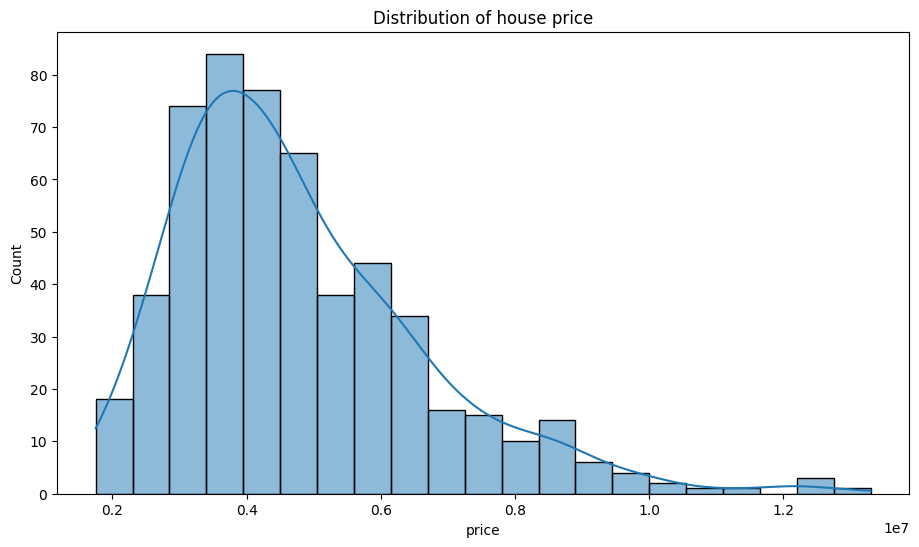

In [42]:
plt.figure(figsize = (11,6))
sns.histplot(df['price'], kde = True)
plt.title('Distribution of house price')
plt.show

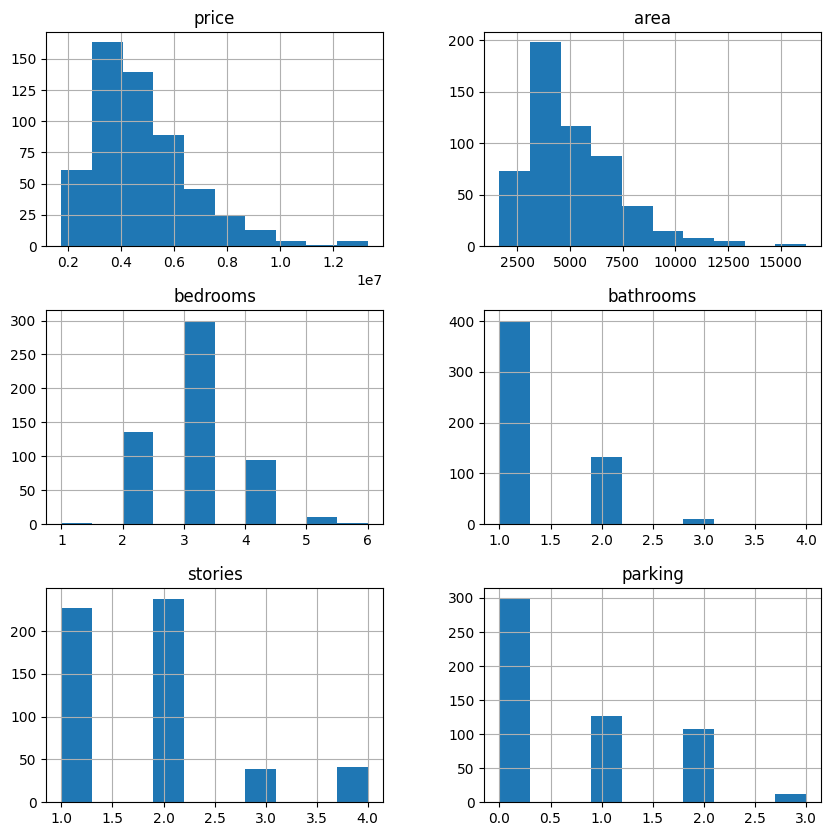

In [43]:
df.hist(figsize=(10,10))
plt.show()

# Visualize relationships between features and price

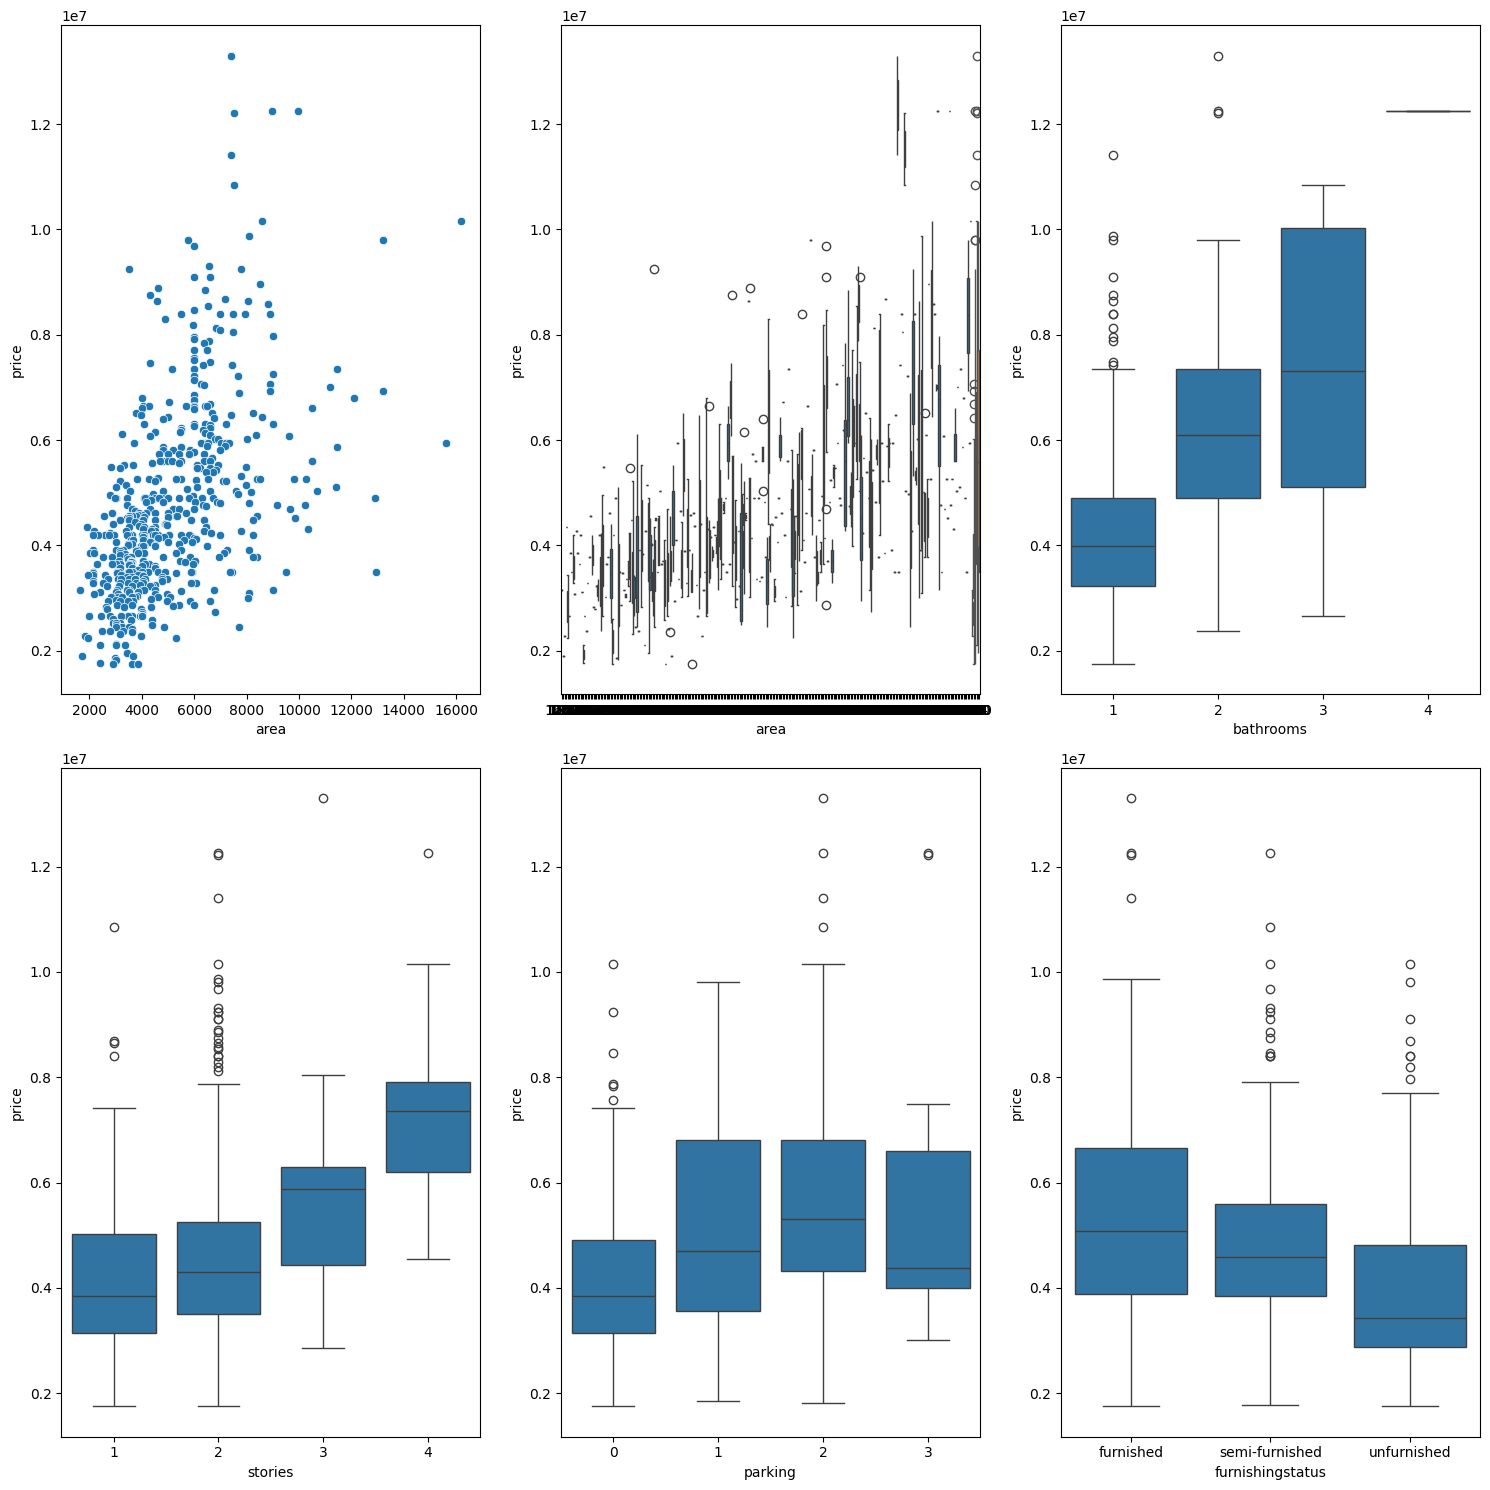

In [46]:
fig, axs = plt.subplots(2,3,figsize=(15,15))
sns.scatterplot(x = 'area' , y = 'price' , data = df, ax = axs[0,0])
sns.boxplot(x = 'area' , y = 'price' , data = df , ax = axs[0,1])
sns.boxplot(x='bedrooms', y='price', data=df, ax=axs[0,1])
sns.boxplot(x='bathrooms', y='price', data=df, ax=axs[0,2])
sns.boxplot(x='stories', y='price', data=df, ax=axs[1,0])
sns.boxplot(x='parking', y='price', data=df, ax=axs[1,1])
sns.boxplot(x='furnishingstatus', y='price', data=df, ax=axs[1,2])
plt.tight_layout()
plt.show()

# Correlation heatmap

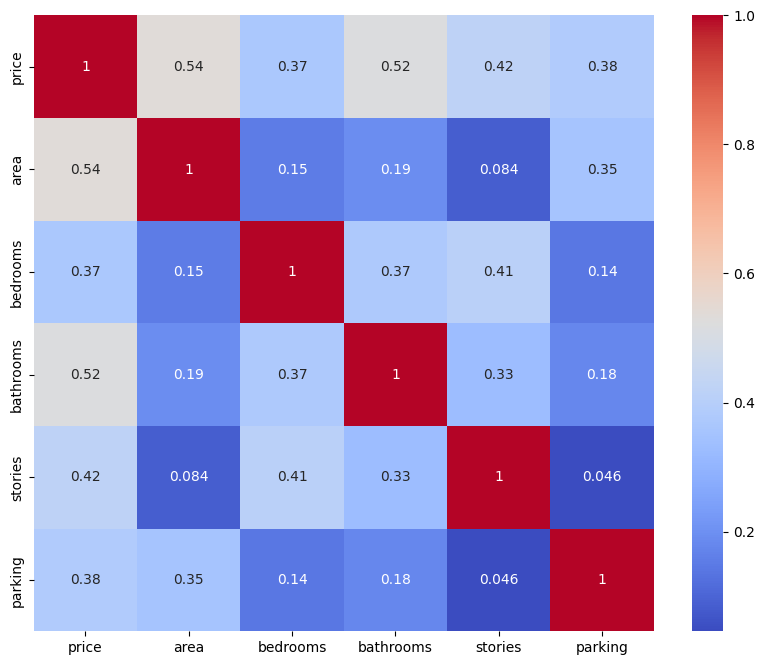

In [49]:
plt.figure(figsize = (10,8))
sns.heatmap(df.corr(numeric_only=True), annot = True, cmap = 'coolwarm')
plt.show()


#  4. Data Preprocessing


In [57]:
change_wordyesnoto_binary = ['mainroad' , 'basement' , 'hotwaterheating' , 'airconditioning' , 'prefarea']
df[change_wordyesnoto_binary] = df[change_wordyesnoto_binary].replace({'yes' : 1 , 'no' : 0})

In [56]:
le = LabelEncoder()
df['furnishingstatus'] = le.fit_transform(df['furnishingstatus'])

In [58]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    int64
dtypes: int64(13)
memory usage: 55.5 KB


# 5. Feature Scaling

In [62]:
x = df.drop('price', axis = 1)
y = df['price']

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# 6. Train-Test Split

In [65]:
x_train , x_test , y_train , y_test = train_test_split(x_scaled , y , test_size = 0.2 , random_state = 42)


In [68]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(x_train,y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [71]:
y_pred = model.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)
print(f"RMSE : {rmse:.2F}")
print(f'R² Score: {r2:.4f}')


RMSE : 1395787.39
R² Score: 0.6146


In [75]:
cv_scores = cross_val_score(model, x_scaled, y, cv=5, scoring='r2')
print(f'Mean CV R²: {cv_scores.mean():.4f}')


Mean CV R²: -11.8630


In [111]:
model_SVR = svm.SVR()
model_SVR.fit(x_train,y_train)
Y_pred = model_SVR.predict(x_test)

print(mean_absolute_percentage_error(y_test, y_pred))

0.21809514767142513


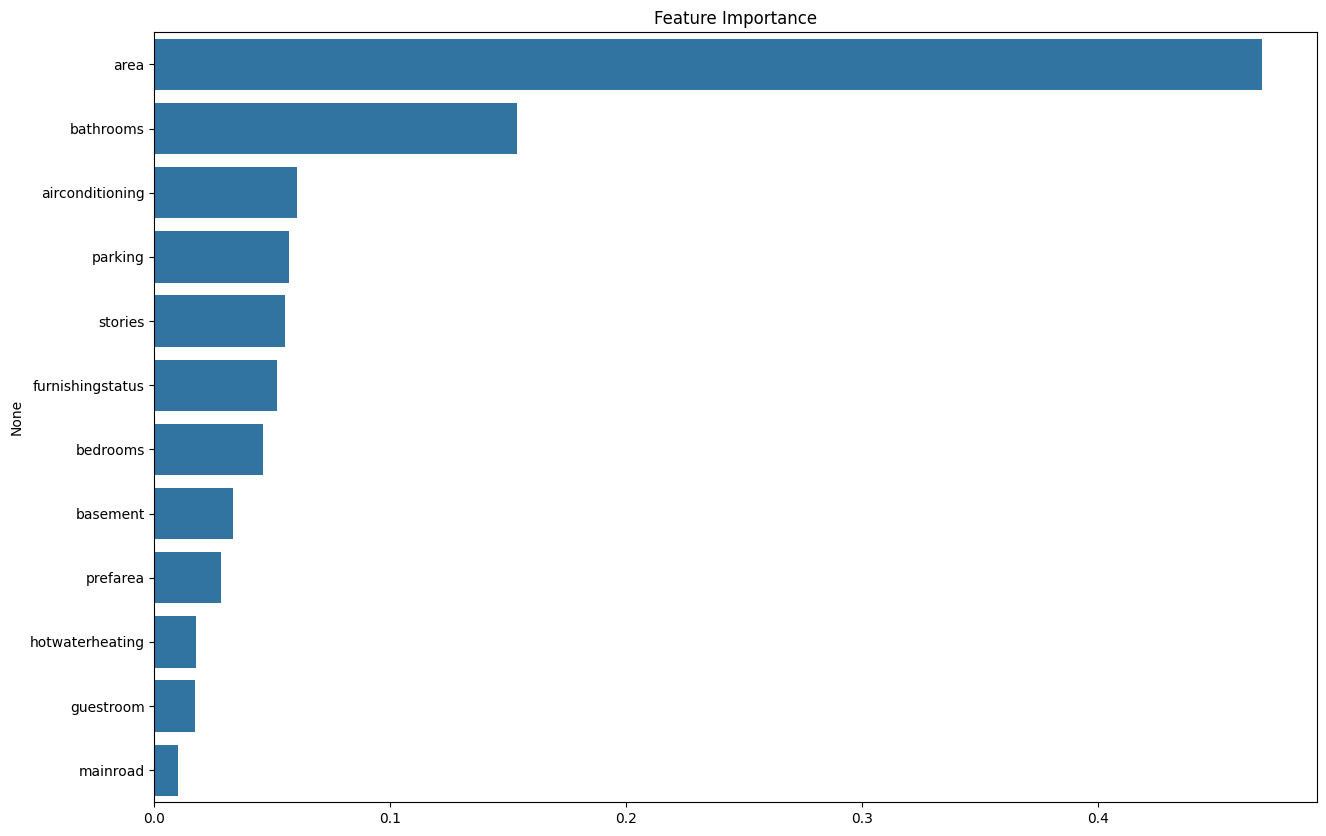

In [94]:
importance = model.feature_importances_
features = x.columns
indices = np.argsort(importance)[::-1]
plt.figure(figsize=(15,10))
sns.barplot(x = importance[indices], y = features[indices])
plt.title("Feature Importance")
plt.show()


In [103]:
user_input = {
    'area': 3000,
    'bedrooms': 4,
    'bathrooms': 2,
    'stories': 2,
    'mainroad': 1,  # 1 for yes, 0 for no
    'guestroom': 0, # 1 for yes, 0 for no
    'basement': 1,  # 1 for yes, 0 for no
    'hotwaterheating': 0, # 1 for yes, 0 for no
    'airconditioning': 2, # 1 for yes, 0 for no
    'parking': 2,
    'prefarea': 1,  # 1 for yes, 0 for no
    'furnishingstatus': 1 # 0: furnished, 1: semi-furnished, 2: unfurnished
}


In [109]:
if user_input:
    user_df = pd.DataFrame([user_input])
    print(user_df)
    user_scaled = scaler.transform(user_df)
    prediction = model.predict(user_scaled)
    print('\n')
    print(f'Predicted House Price: {prediction[0]:.2f}\n')
else:
    print('Please fill in the user_input dictionary above to get a prediction.')


   area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
0  3000         4          2        2         1          0         1   

   hotwaterheating  airconditioning  parking  prefarea  furnishingstatus  
0                0                2        2         1                 1  


Predicted House Price: 5375142.50

